In [2]:
import numpy as np
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
from as7341_calibrate import basic_counts, calibrated_raw
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression


In [3]:
CH = ['f1_415', 'f2_445', 'f3_480', 'f4_515', 'f5_555',
            'f6_590', 'f7_630', 'f8_680', 'clear', 'nir']

DATA = "../data/"
files = glob(f"{DATA}/*.csv")

df = pd.DataFrame()

for file in files:
      tdf = pd.read_csv(file)
      df = pd.concat([df,tdf])



### PAR regression - spectrally UNcalibrated `basic_counts` for whole dataset
Use the AS7341 raw channel converted to `basic_counts` to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 channels.

Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 14.63
  RMSE: 22.06
  R^2 : 0.9988
Coefficients: {'f1_415': np.float64(381.049293201115), 'f2_445': np.float64(201.98540813059785), 'f3_480': np.float64(-9.157353488342249), 'f4_515': np.float64(258.70916067994574), 'f5_555': np.float64(-133.65133889492387), 'f6_590': np.float64(70.55856333947926), 'f7_630': np.float64(39.8418004499425), 'f8_680': np.float64(-12.623817394118781), 'clear': np.float64(16.94740500585985), 'nir': np.float64(-38.219397243779326)}
Intercept: 5.36918919771756


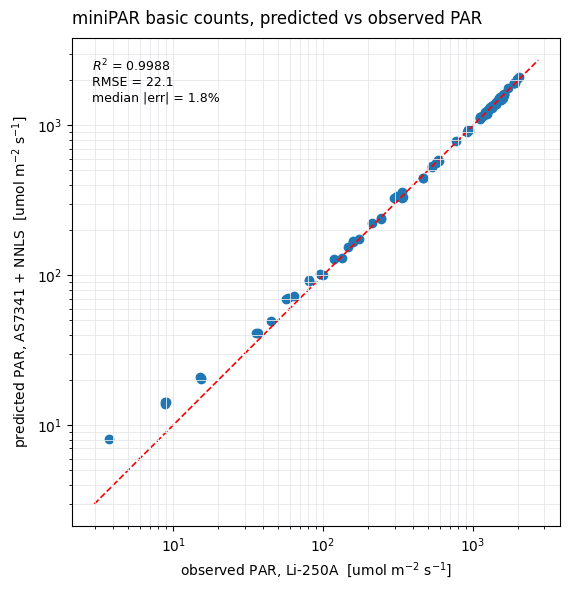

In [4]:


X = basic_counts(df)
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(CH, lin.coef_)))
print("Intercept:", lin.intercept_)



lim = (0.8 * min(Y.min(), pred[pred > 0].min()), 1.3 * max(Y.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR basic counts, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()


### PAR regression - spectrally CALIBRATED `basic_counts` for whole dataset
Use the AS7341 raw channel converted to `basic_counts`, offset corrected and spectrally calibrated as described in AN000633 (§2.1, §2.2, §2.4) to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 calibrated channels.

Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 14.64
  RMSE: 22.06
  R^2 : 0.9988
Coefficients: {'f1_415': np.float64(10.923991276225875), 'f2_445': np.float64(3.089892733159165), 'f3_480': np.float64(-0.12294853833321062), 'f4_515': np.float64(4.0838162949872565), 'f5_555': np.float64(-2.3532169542641683), 'f6_590': np.float64(1.3337376217788137), 'f7_630': np.float64(0.8171288922472033), 'f8_680': np.float64(-0.29757466933360877), 'clear': np.float64(0.537299343932053), 'nir': np.float64(-6.612942776131823)}
Intercept: 7.807621004083558


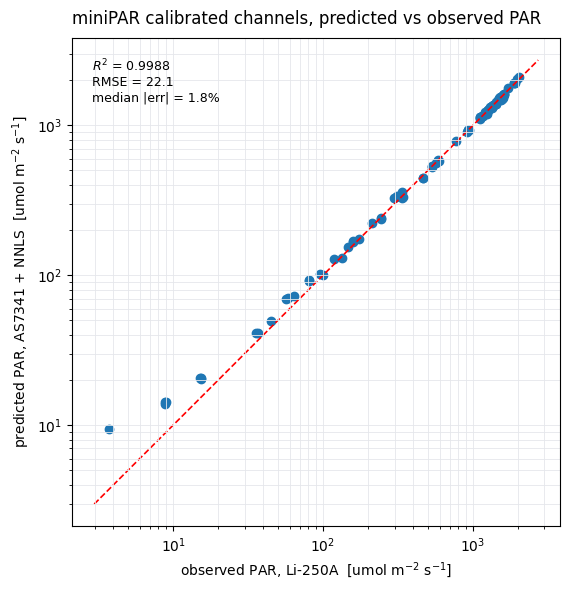

In [5]:
X = calibrated_raw(df) # use the spectrally calibrated
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficients:", dict(zip(CH, lin.coef_)))
print("Intercept:", lin.intercept_)



lim = (0.8 * min(Y.min(), pred[pred > 0].min()), 1.3 * max(Y.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR calibrated channels, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()

### PAR from the SUMMED calibrated channels — 
Use the AS7341 raw channel converted to `basic_counts`, offset corrected and spectrally calibrated as described in AN000633 (§2.1, §2.2, §2.4) to predict PAR measured with the golden reference;
`tia_par` (Li-250A) regressed on the 10 corrected channels. 
Coefficients are forced `>= 0` (`scipy.optimize.nnls`).


Total samples: 462
Training samples: 369, Testing samples: 93
Linear regression
  MAE : 128.7
  RMSE: 158.6
  R^2 : 0.9364
Coefficient: [0.88294368]
Intercept: 55.163479843680875


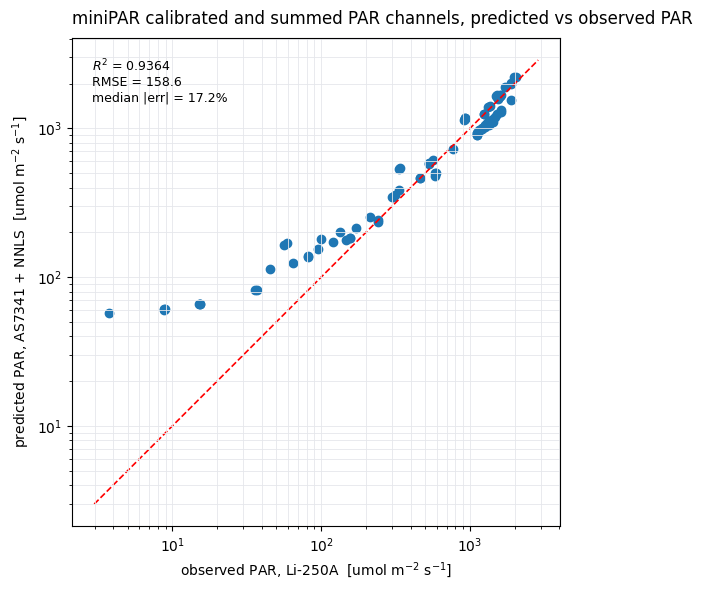

In [18]:

par = calibrated_raw(df)[['cal_f1_415', 'cal_f2_445', 'cal_f3_480', 'cal_f4_515', 'cal_f5_555',
       'cal_f6_590', 'cal_f7_630', 'cal_f8_680']].sum(axis=1) # use the spectrally calibrated and par like SUMMED channels 

X = par.to_numpy(float).reshape(-1,1)
Y = df.tia_par.to_numpy(float)

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


print("Total samples:", len(X))
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ---- Model ----
lin = LinearRegression()
lin.fit(X_train, y_train)

# ---- Predict + metrics ----
pred = lin.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

res = pred - y_test
mape = float(np.median(np.abs(res) / y_test) * 100)

print("Linear regression")
print(f"  MAE : {mae:.4g}")
print(f"  RMSE: {rmse:.4g}")
print(f"  R^2 : {r2:.4g}")
print("Coefficient:", lin.coef_)
print("Intercept:", lin.intercept_)



lim = (0.8 * min(y_test.min(), pred[pred > 0].min()),1.3 * max(y_test.max(), pred.max()))

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(y_test,pred)
ax.plot(lim, lim, color='r', lw=1.2, ls='--', zorder=1, label='1:1')
ax.set(xscale='log', yscale='log',
       xlabel='observed PAR, Li-250A  [umol m$^{-2}$ s$^{-1}$]',
       ylabel='predicted PAR, AS7341 + NNLS  [umol m$^{-2}$ s$^{-1}$]')
ax.set_title('miniPAR calibrated and summed PAR channels, predicted vs observed PAR', loc='left', pad=10)
ax.set_aspect('equal')
ax.grid(True, which='both', color='#e5e7eb', lw=0.6, zorder=0)
ax.annotate('$R^2$ = %.4f\nRMSE = %.1f\nmedian |err| = %.1f%%' % (r2, rmse, mape),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top',
           fontsize=9)
fig.tight_layout()
plt.show()